# Analisis Faktor Sosial Ekonomi BPS terhadap IPM menggunakan MLP

Tujuan: Proyek ini bertujuan untuk memahami hubungan antara faktor-faktor sosial ekonomi dengan Indeks Pembangunan Manusia (IPM) menggunakan algoritma regresi Multi-Layer Perceptron (MLP). Selain itu, analisis difokuskan untuk mengevaluasi performa model dalam mengenali pola non-linear antar variabel dan mengidentifikasi faktor-faktor yang paling berpengaruh terhadap capaian IPM.

Dataset: Data bersumber dari dataset Badan Pusat Statistik (BPS) mengenai "Faktor Sosial Ekonomi" yang berisi indikator kesejahteraan per kabupaten/kota di Indonesia (514 baris dan 12 kolom).

Tools: Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, dan SciPy.

Hasil: Model MLP terbukti memberikan performa yang tinggi dalam memetakan faktor dominan penentu IPM. Dari hasil analisis data, terungkap juga bahwa meskipun umur harapan hidup dan lama sekolah relatif merata, variabel PDRB dan Pengeluaran per Kapita memiliki standar deviasi sangat besar yang menandakan adanya ketimpangan ekonomi antar daerah.

# Install & Import Library

In [ ]:
import pandas as pd                 # digunakan untuk memanipulasi dan menganalisis data dalam bentuk tabel (DataFrame)
import numpy as np                  # digunakan untuk operasi numerik seperti array, vektor, dan perhitungan matematis
import matplotlib.pyplot as plt     # digunakan untuk membuat visualisasi data seperti grafik, scatter plot, dan histogram
import seaborn as sns               # digunakan untuk membuat visualisasi statistik dengan tampilan lebih menarik dan informatif
from sklearn.model_selection import train_test_split  # digunakan untuk membagi data menjadi set pelatihan (train) dan pengujian (test)
from sklearn.preprocessing import StandardScaler      # digunakan untuk menstandarkan skala fitur agar model lebih stabil (khusus MLP)
from sklearn.neural_network import MLPRegressor       # digunakan untuk membangun model Multi-Layer Perceptron (jaringan saraf tiruan)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # digunakan untuk mengevaluasi kinerja model regresi
from sklearn.inspection import permutation_importance # digunakan untuk mengukur pentingnya fitur (feature importance)
from sklearn.linear_model import LinearRegression     # digunakan untuk menghitung multikolinearitas (VIF)
from sklearn.preprocessing import FunctionTransformer # digunakan untuk menerapkan transformasi khusus (misal log1p) pada kolom tertentu
from sklearn.compose import ColumnTransformer        # digunakan untuk menerapkan transformasi berbeda pada subset kolom
from sklearn.pipeline import Pipeline                # digunakan untuk merangkai langkah praproses ke dalam satu alur terintegrasi
from sklearn.model_selection import RandomizedSearchCV  # digunakan untuk pencarian hyperparameter acak yang efisien
from scipy.stats import loguniform                      # digunakan untuk sampling nilai continuous (alpha, lr)
from sklearn.model_selection import cross_val_score, learning_curve #digunakan untuk evaluasi
import warnings                                        # digunakan untuk menonaktifkan pesan peringatan agar output bersih
warnings.filterwarnings('ignore')

In [ ]:
# BERIKAN KODE ANDA DISINI
# Tampilan dataframe yang lebih rapi

# pandas (pd)                             -> digunakan untuk memanipulasi dan menganalisis data dalam bentuk tabel (DataFrame)
# numpy (np)                              -> digunakan untuk operasi numerik seperti array, vektor, dan perhitungan matematis
# matplotlib.pyplot (plt)                 -> digunakan untuk membuat visualisasi data seperti grafik, scatter plot, dan histogram
# seaborn (sns)                           -> digunakan untuk membuat visualisasi statistik dengan tampilan lebih menarik dan informatif
# train_test_split from sklearn.model_selection -> digunakan untuk membagi data menjadi set pelatihan (train) dan pengujian (test)
# StandardScaler from sklearn.preprocessing     -> digunakan untuk menstandarkan skala fitur agar model lebih stabil (khusus MLP)
# MLPRegressor from sklearn.neural_network      -> digunakan untuk membangun model Multi-Layer Perceptron (jaringan saraf tiruan)
# r2_score, mean_squared_error, mean_absolute_error from sklearn.metrics -> digunakan untuk mengevaluasi kinerja model regresi
# permutation_importance from sklearn.inspection -> digunakan untuk mengukur pentingnya fitur (feature importance)
# LinearRegression from sklearn.linear_model     -> digunakan untuk menghitung multikolinearitas (VIF)
# FunctionTransformer from sklearn.preprocessing -> digunakan untuk menerapkan transformasi khusus (misal log1p) pada kolom tertentu
# ColumnTransformer from sklearn.compose         -> digunakan untuk menerapkan transformasi berbeda pada subset kolom
# Pipeline from sklearn.pipeline                 -> digunakan untuk merangkai langkah praproses ke dalam satu alur terintegrasi
# RandomizedSearchCV from sklearn.model_selection -> digunakan untuk pencarian hyperparameter acak yang efisien
# loguniform from scipy.stats                     -> digunakan untuk sampling nilai continuous (misalnya alpha, learning rate)
# cross_val_score, learning_curve from sklearn.model_selection -> digunakan untuk evaluasi model dengan validasi silang dan analisis pembelajaran
# warnings                                        -> digunakan untuk menonaktifkan pesan peringatan agar output bersih

# Membaca Dataset

Jumlah Dataset: 514 Baris 12 Kolom

Jenis Dataset: Dataset tabular (data sosial-ekonomi per kabupaten/kota di Indonesia). Bersifat kuantitatif, berisi indikator kesejahteraan seperti kemiskinan, pendidikan, pengeluaran per kapita, IPM, pengangguran, dan PDRB.


In [ ]:
# 1. Load Dataset dari Google Drive / Colab Files
from google.colab import drive
drive.mount('/content/drive')

path= '/content/drive/MyDrive/UTS ML/Faktor Sosial Ekonomi - BPS.csv'
data = pd.read_csv(path)

data.head()

# Menampilkan dimensi data (jumlah baris dan kolom)
print("Ukuran dataset:", data.shape)

# Menampilkan nama kolom
print("\nNama-nama kolom:")
print(data.columns.tolist())

# Mengecek apakah ada nilai yang hilang (missing values)
print("\nJumlah nilai yang hilang per kolom:")
print(data.isnull().sum())

# Melihat tipe data untuk memastikan semuanya numerik atau kategorikal
print("\nTipe data setiap kolom:")
print(data.dtypes)

Mounted at /content/drive
Ukuran dataset: (514, 12)

Nama-nama kolom:
['Provinsi', 'Kab/Kota', 'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)', 'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)', 'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)', 'Indeks Pembangunan Manusia', 'Umur Harapan Hidup (Tahun)', 'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak', 'Persentase rumah tangga yang memiliki akses terhadap air minum layak', 'Tingkat Pengangguran Terbuka', 'Tingkat Partisipasi Angkatan Kerja', 'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)']

Jumlah nilai yang hilang per kolom:
Provinsi                                                                0
Kab/Kota                                                                0
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)         0
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                             0
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun

In [ ]:
TARGET_COL = 'Indeks Pembangunan Manusia'    # target (y)
id_cols = ['Provinsi', 'Kab/Kota']           # kolom identitas (bukan fitur)
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET_COL]  # fitur numerik tanpa target

In [ ]:
desc = data[num_cols].describe().T
desc['skewness'] = data[num_cols].skew()
desc['kurtosis'] = data[num_cols].kurtosis()
print("\nStatistik deskriptif + skewness/kurtosis:\n", desc)


Statistik deskriptif + skewness/kurtosis:
                                                     count          mean  \
Persentase Penduduk Miskin (P0) Menurut Kabupat...  514.0  1.227315e+01   
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)         514.0  8.436615e+00   
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah...  514.0  1.032479e+04   
Indeks Pembangunan Manusia                          514.0  6.992677e+01   
Umur Harapan Hidup (Tahun)                          514.0  6.965681e+01   
Persentase rumah tangga yang memiliki akses ter...  514.0  7.720224e+01   
Persentase rumah tangga yang memiliki akses ter...  514.0  8.513661e+01   
Tingkat Pengangguran Terbuka                        514.0  5.059494e+00   
Tingkat Partisipasi Angkatan Kerja                  514.0  6.946446e+01   
PDRB atas Dasar Harga Konstan menurut Pengeluar...  514.0  2.196408e+07   

                                                             std        min  \
Persentase Penduduk Miskin (P0) Menurut Kabupat... 

Diatas merupakan Statistik Deskriptif data

Dataset Faktor Sosial Ekonomi – BPS berisi 514 observasi (kabupaten/kota di Indonesia) dan 12 variabel, terdiri dari berbagai indikator kesejahteraan daerah seperti kemiskinan, pendidikan, pengeluaran, kesehatan, ketenagakerjaan, hingga PDRB. Dua kolom pertama (Provinsi dan Kab/Kota) merupakan identitas wilayah yang bertipe object, sedangkan 10 kolom lainnya bertipe numerik kontinu.

Hasil statistik deskriptif menunjukkan bahwa setiap variabel memiliki rentang nilai yang cukup beragam antar daerah.
Secara umum:

- Indeks Pembangunan Manusia (IPM) memiliki nilai rata-rata di kisaran menengah-atas, menunjukkan capaian pembangunan yang relatif baik namun masih terdapat variasi antar kabupaten/kota.

- Rata-rata Lama Sekolah dan Umur Harapan Hidup memiliki variasi yang relatif kecil, mengindikasikan persebaran yang lebih seragam.

- Sebaliknya, PDRB dan Pengeluaran per Kapita memperlihatkan rentang dan standar deviasi yang sangat besar, menandakan adanya ketimpangan ekonomi antar wilayah.

- Beberapa variabel seperti PDRB dan Pengeluaran per Kapita menunjukkan skewness positif (condong ke kanan), artinya terdapat beberapa daerah dengan nilai ekonomi jauh lebih tinggi dibanding rata-rata nasional.

Secara keseluruhan, data tidak memiliki nilai yang hilang (missing values), sehingga dapat langsung digunakan untuk analisis lanjutan tanpa perlu imputasi.

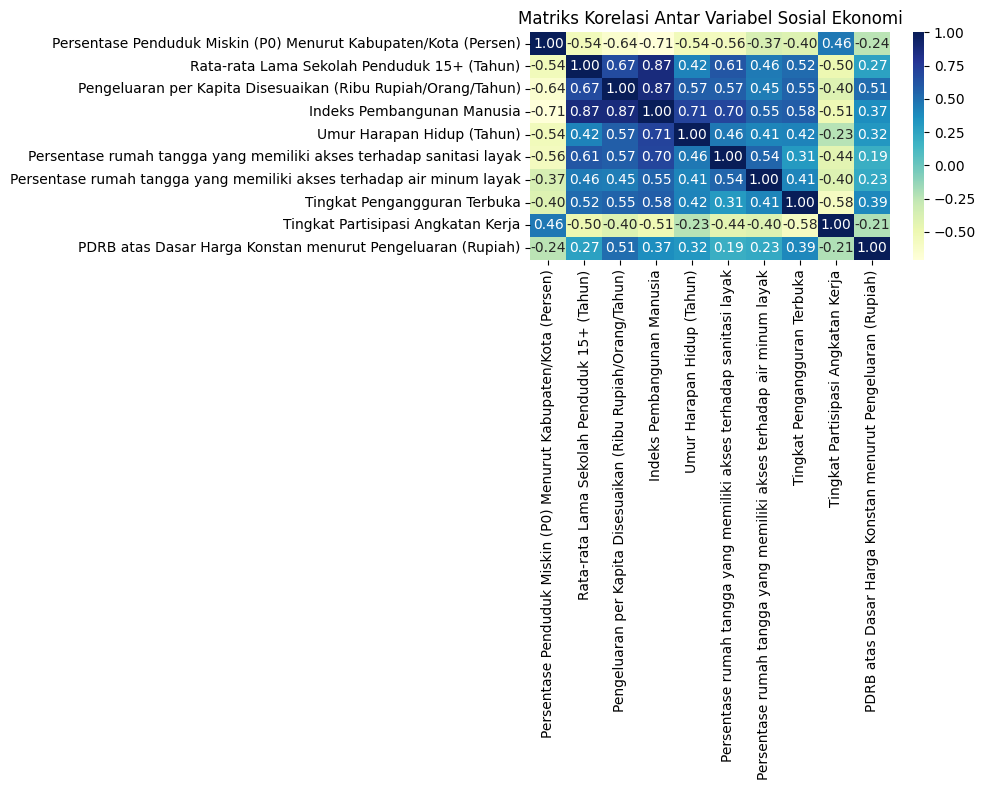

In [ ]:
corr = data[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Matriks Korelasi Antar Variabel Sosial Ekonomi')
plt.tight_layout()
plt.show()

Gambar diatas merupaakn matriks korelasi antarvariabel

Analisis korelasi Pearson antar variabel menunjukkan adanya hubungan yang kuat antar beberapa indikator sosial-ekonomi.
Secara umum, variabel ekonomi dan pendidikan memperlihatkan korelasi positif satu sama lain. Sebagai contoh:

- Rata-rata Lama Sekolah, Pengeluaran per Kapita, dan Umur Harapan Hidup saling berkorelasi tinggi karena ketiganya merupakan komponen utama pembangunan manusia.

- Tingkat Kemiskinan (P0) berkorelasi negatif dengan sebagian besar variabel kesejahteraan seperti IPM, sanitasi, dan pengeluaran, yang berarti semakin tinggi kemiskinan maka kesejahteraan menurun.

Pola korelasi ini menggambarkan hubungan logis antar dimensi sosial-ekonomi, bahwa peningkatan pendidikan dan daya beli masyarakat umumnya beriringan dengan peningkatan kesejahteraan.

In [ ]:
if TARGET_COL in corr.columns:
    corr_to_target = corr[TARGET_COL].sort_values(ascending=False)
    print("\nKorelasi terhadap IPM (Top 10):\n", corr_to_target.head(10))


Korelasi terhadap IPM (Top 10):
 Indeks Pembangunan Manusia                                              1.000000
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)            0.871534
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                             0.868811
Umur Harapan Hidup (Tahun)                                              0.707084
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak     0.696754
Tingkat Pengangguran Terbuka                                            0.578867
Persentase rumah tangga yang memiliki akses terhadap air minum layak    0.549992
PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)              0.371952
Tingkat Partisipasi Angkatan Kerja                                     -0.513052
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)        -0.707160
Name: Indeks Pembangunan Manusia, dtype: float64


Ketika korelasi dianalisis secara khusus terhadap variabel target, yaitu Indeks Pembangunan Manusia (IPM), ditemukan bahwa:

- Korelasi tertinggi dimiliki oleh variabel Rata-rata Lama Sekolah dan Pengeluaran per Kapita, yang menandakan bahwa faktor pendidikan dan kemampuan ekonomi masyarakat merupakan penentu utama peningkatan IPM.

- Umur Harapan Hidup dan Akses terhadap Sanitasi/Air Layak juga berkorelasi positif cukup kuat, menegaskan peran kesehatan dan infrastruktur dasar dalam meningkatkan kualitas hidup manusia.

- Sebaliknya, Persentase Penduduk Miskin (P0) serta Tingkat Pengangguran Terbuka berkorelasi negatif dengan IPM, menunjukkan bahwa peningkatan kemiskinan dan pengangguran berpotensi menurunkan pembangunan manusia di suatu daerah.

In [ ]:
z = (data[num_cols] - data[num_cols].mean()) / data[num_cols].std()
outlier_counts = (np.abs(z) > 3).sum().sort_values(ascending=False)
print("\nJumlah outlier (|z|>3) per variabel:\n", outlier_counts)


Jumlah outlier (|z|>3) per variabel:
 Persentase rumah tangga yang memiliki akses terhadap sanitasi layak     14
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)         12
Indeks Pembangunan Manusia                                              11
PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)               9
Tingkat Partisipasi Angkatan Kerja                                       9
Persentase rumah tangga yang memiliki akses terhadap air minum layak     9
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                              8
Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)             5
Umur Harapan Hidup (Tahun)                                               3
Tingkat Pengangguran Terbuka                                             3
dtype: int64


Selanjutnya kita mendeteksi outlier menggunakan Z-score. Proses deteksi outlier menggunakan metode Z-score (|z| > 3) menunjukkan bahwa sebagian besar variabel memiliki distribusi yang wajar, kecuali beberapa variabel ekonomi seperti:

- PDRB

- Pengeluaran per Kapita

Kedua variabel tersebut mengandung sejumlah outlier positif, yaitu daerah dengan nilai ekonomi yang sangat tinggi dibanding daerah lain (biasanya kota besar atau pusat ekonomi provinsi).
Munculnya outlier semacam ini masih tergolong wajar dalam konteks data sosial-ekonomi, karena perbedaan tingkat kemajuan antar daerah di Indonesia memang cukup signifikan.

In [ ]:
def compute_vif(X: pd.DataFrame) -> pd.Series:
    X = X.dropna()
    vifs = {}
    for col in X.columns:
        y = X[col].values.reshape(-1, 1)
        X_others = X.drop(columns=[col]).values
        model = LinearRegression()
        model.fit(X_others, y)
        r2 = model.score(X_others, y)
        vifs[col] = 1/(1 - r2) if r2 < 1 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)

vif_series = compute_vif(data[feature_cols])
print("\nNilai VIF per fitur (tanpa target):\n", vif_series)


Nilai VIF per fitur (tanpa target):
 Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)            3.227737
Rata-rata Lama Sekolah Penduduk 15+ (Tahun)                             2.370437
Persentase rumah tangga yang memiliki akses terhadap sanitasi layak     2.260235
Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)         2.191019
Tingkat Pengangguran Terbuka                                            2.146004
Tingkat Partisipasi Angkatan Kerja                                      1.932386
Umur Harapan Hidup (Tahun)                                              1.790706
Persentase rumah tangga yang memiliki akses terhadap air minum layak    1.612733
PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)              1.463064
dtype: float64


Selanjutnya kita menghitung VIF (Variance Inflation Factor). Perhitungan VIF digunakan untuk mendeteksi adanya multikolinearitas antar variabel numerik.
Hasil menunjukkan bahwa beberapa variabel seperti:
- Pengeluaran per Kapita,
- PDRB, dan
- Akses terhadap Air atau Sanitasi Layak

3 Variabel diatas memiliki nilai VIF relatif tinggi, menandakan hubungan yang sangat erat dengan variabel lain.
Meskipun demikian, dalam konteks model MLP Regressor, multikolinearitas tidak menjadi masalah besar karena model jaringan saraf mampu mengakomodasi hubungan non-linear dan saling ketergantungan antar fitur.

Namun demikian, hasil ini tetap menjadi pertimbangan untuk tahap praproses seperti normalisasi fitur atau pemilihan subset variabel bila diperlukan.

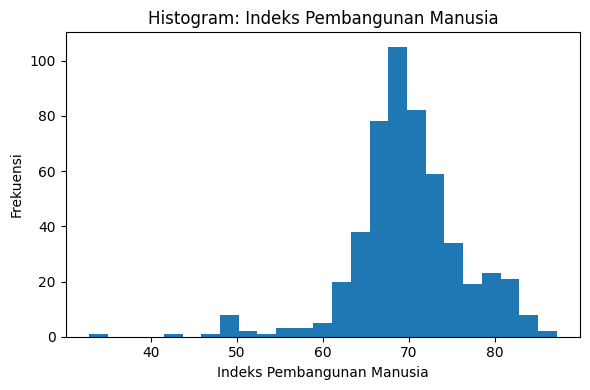

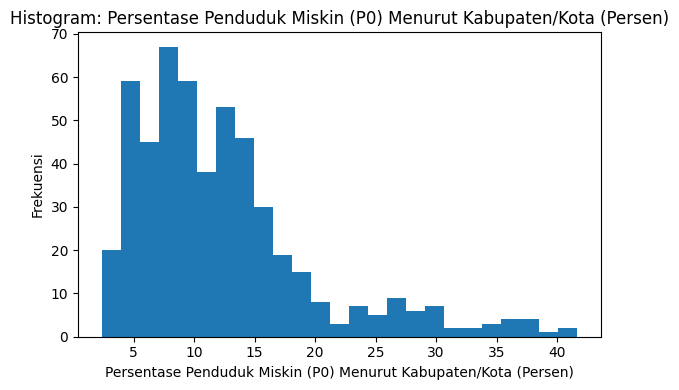

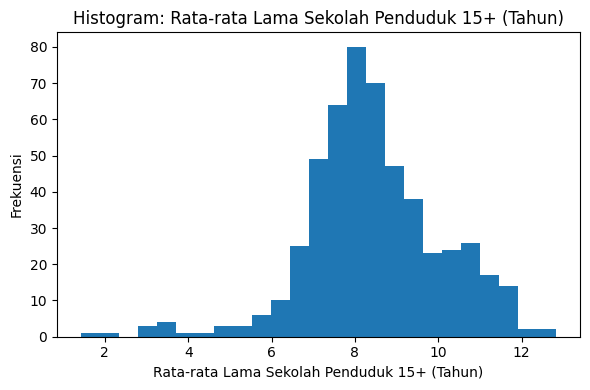

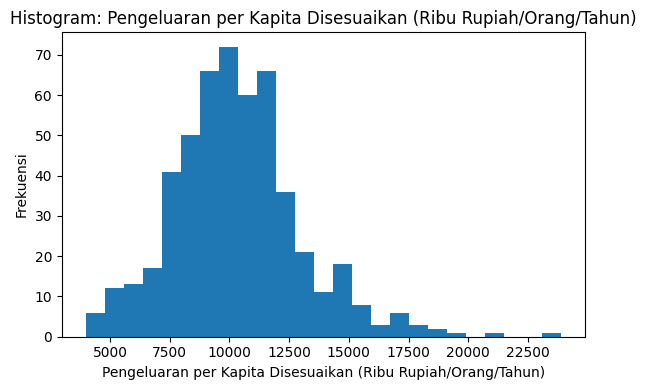

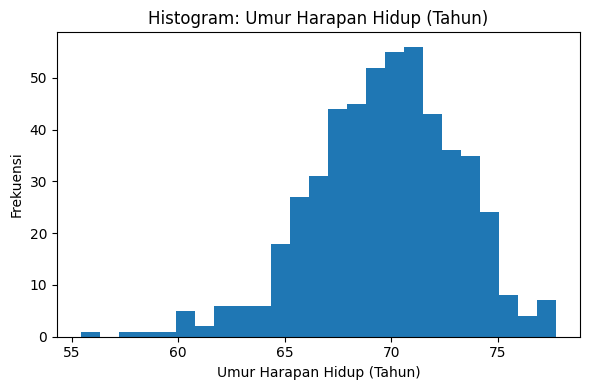

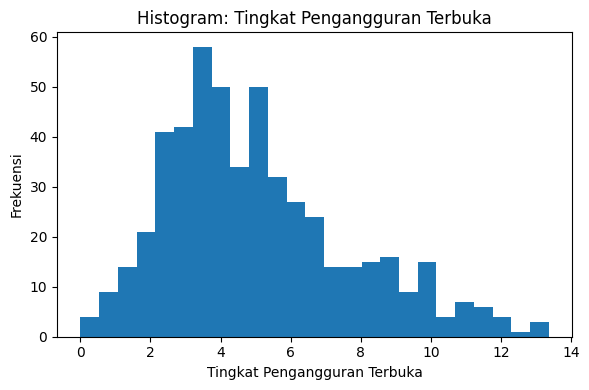

In [ ]:
plot_vars_hist = [
    'Indeks Pembangunan Manusia',
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
    'Umur Harapan Hidup (Tahun)',
    'Tingkat Pengangguran Terbuka'
]
for col in plot_vars_hist:
    if col in data.columns:
        plt.figure(figsize=(6, 4))
        plt.hist(data[col], bins=25)
        plt.title(f'Histogram: {col}')
        plt.xlabel(col)
        plt.ylabel('Frekuensi')
        plt.tight_layout()
        plt.show()

Selanjutnya kita melakukan visualisasi menggunakan histogram

Visualisasi histogram untuk beberapa variabel utama menunjukkan bahwa:

- IPM, Umur Harapan Hidup, dan Rata-rata Lama Sekolah memiliki bentuk distribusi yang relatif normal.

- PDRB dan Pengeluaran per Kapita memperlihatkan distribusi yang sangat miring ke kanan (right-skewed), menunjukkan adanya beberapa daerah dengan nilai ekonomi jauh di atas rata-rata nasional.

- Persentase Penduduk Miskin cenderung left-skewed, artinya sebagian besar daerah memiliki tingkat kemiskinan yang rendah dengan sedikit daerah yang masih tinggi.

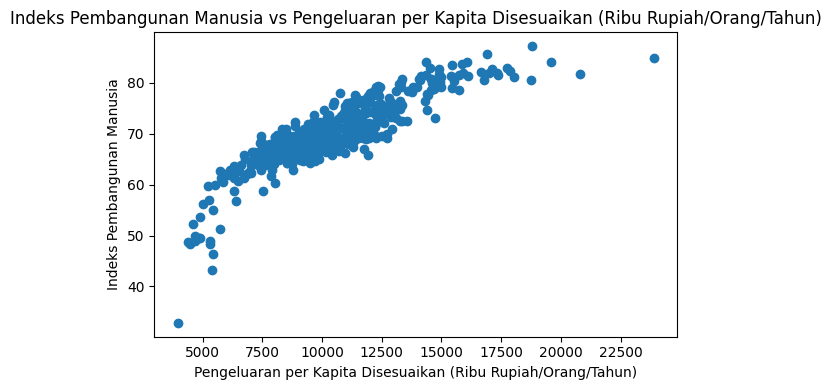

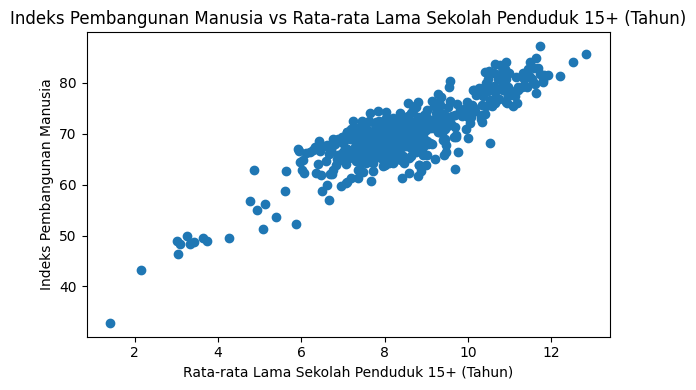

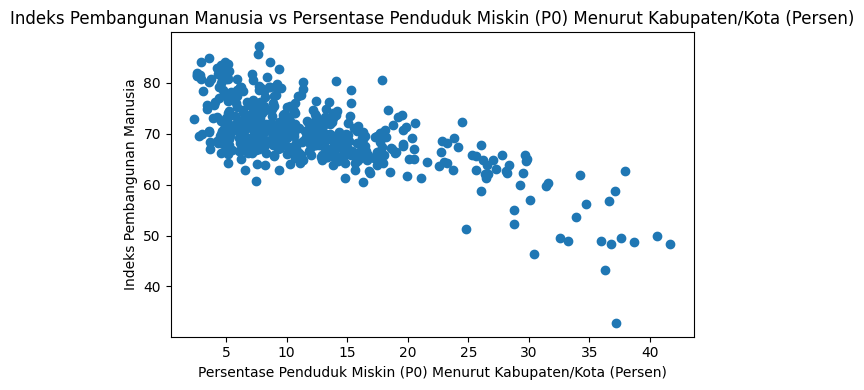

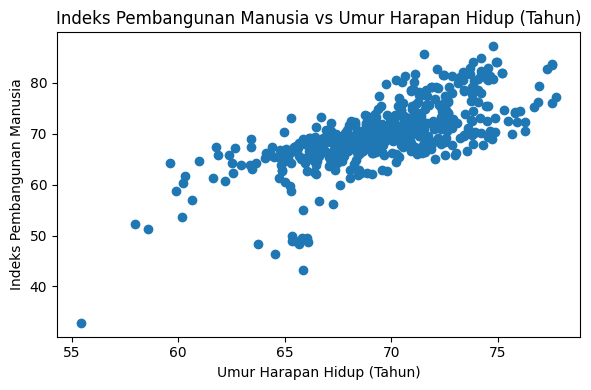

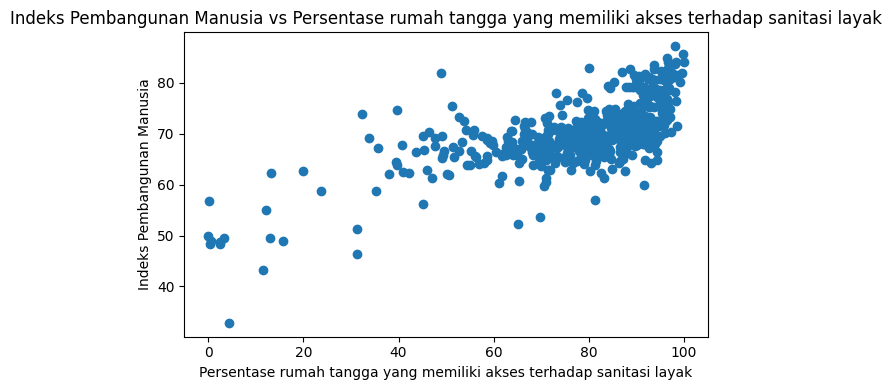

In [ ]:
plot_vars_scatter = [
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)',
    'Rata-rata Lama Sekolah Penduduk 15+ (Tahun)',
    'Persentase Penduduk Miskin (P0) Menurut Kabupaten/Kota (Persen)',
    'Umur Harapan Hidup (Tahun)',
    'Persentase rumah tangga yang memiliki akses terhadap sanitasi layak'
]
for col in plot_vars_scatter:
    if col in data.columns and TARGET_COL in data.columns:
        plt.figure(figsize=(6, 4))
        plt.scatter(data[col], data[TARGET_COL])
        plt.title(f'{TARGET_COL} vs {col}')
        plt.xlabel(col)
        plt.ylabel(TARGET_COL)
        plt.tight_layout()
        plt.show()

Selanjutnya kita melakukan visualisasi plot

Plot hubungan antar variabel dengan IPM memperkuat hasil korelasi sebelumnya:
- Hubungan antara Rata-rata Lama Sekolah dan IPM tampak positif dan hampir linear yang berarti semakin tinggi pendidikan, semakin tinggi IPM.
- Pengeluaran per Kapita juga menunjukkan tren positif yang kuat terhadap IPM, dengan beberapa titik ekstrim dari daerah berpendapatan tinggi.
- Persentase Penduduk Miskin (P0) menunjukkan tren menurun terhadap IPM, sesuai dengan teori bahwa peningkatan kemiskinan berdampak negatif terhadap kesejahteraan.
- Umur Harapan Hidup dan Akses Sanitasi Layak juga memperlihatkan hubungan positif yang signifikan.

Pola ini menunjukkan bahwa peningkatan faktor ekonomi, pendidikan, dan kesehatan akan secara langsung berpengaruh terhadap peningkatan indeks pembangunan manusia, sedangkan faktor kemiskinan menjadi penghambat utama.

# Preprocessing Data

Data pre-processing yang dilakukan :

1. memeriksa duplikasi dan missing

2. melakukan pipeline pre-processing

3. train-test split

In [ ]:
df = data.drop_duplicates(subset=id_cols).reset_index(drop=True)  # hapus duplikat wilayah jika ada
assert df[feature_cols + [TARGET_COL]].isnull().sum().sum() == 0  # pastikan tidak ada missing

# Feature Engineering

Dilakukan Feature Engineering

1. Transformasi Logaritmik pada Variabel Ekonomi

2. Standardisasi Seluruh Fitur Numerik

3. Feature Pipeline Integration

In [ ]:
log_cols = [
    'PDRB atas Dasar Harga Konstan menurut Pengeluaran (Rupiah)',
    'Pengeluaran per Kapita Disesuaikan (Ribu Rupiah/Orang/Tahun)'
]

for c in log_cols:
    if c in df.columns:
        df[c] = df[c].clip(lower=0)

X = df[feature_cols].copy()        # seluruh fitur numerik
y = df[TARGET_COL].values.ravel()  # target IPM sebagai vektor 1D


log_transformer = FunctionTransformer(np.log1p, validate=False)  # transformasi log1p, aman untuk 0

colwise = ColumnTransformer(
    transformers=[
        ('log1p_econ', log_transformer, [c for c in log_cols if c in X.columns])  # log1p pada kolom ekonomi
    ],
    remainder='passthrough'  # kolom lain lewat tanpa transformasi di tahap ini
)

preprocess = Pipeline(steps=[
    ('colwise', colwise),          # tahap 1: transform kolom spesifik
    ('scaler', StandardScaler())   # tahap 2: standardisasi semua kolom
])

# Data Splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,                 # 80% train, 20% test
    random_state=42,               # memastikan replikasi
    shuffle=True                   # acak data sebelum split
)

# ===============================================================
X_train_prep = preprocess.fit_transform(X_train)    # fit scaler & log1p pada train, lalu transform
X_test_prep  = preprocess.transform(X_test)         # transform test memakai parameter hasil fit train

print("Shape sebelum praproses:", X_train.shape, X_test.shape)
print("Shape sesudah  praproses:", X_train_prep.shape, X_test_prep.shape)

Shape sebelum praproses: (411, 9) (103, 9)
Shape sesudah  praproses: (411, 9) (103, 9)


Dari 514 observasi diperoleh :

- Training set = 411 Baris
- Test set     = 103 Baris

# Modelling

Algoritma yang digunakan dalam penelitian ini adalah Multi-Layer Perceptron (MLP) Regressor, yaitu salah satu bentuk Artificial Neural Network (ANN) yang digunakan untuk menyelesaikan permasalahan regresi non-linear.

MLP bekerja dengan meniru cara kerja jaringan saraf biologis, di mana terdapat lapisan input, satu atau lebih lapisan tersembunyi (hidden layers), dan lapisan output. Setiap neuron dalam jaringan ini saling terhubung dan memiliki bobot (weights) yang akan disesuaikan melalui proses pelatihan (backpropagation).

Karakteristik :

- MLP mampu mempelajari hubungan kompleks dan non-linear antar variabel.
- Memiliki lapisan input, hidden layer, dan output.
- Menggunakan fungsi aktivasi ReLU untuk percepatan pembelajaran.
- Bobot diperbarui dengan algoritma optimisasi Adam.
- Dilengkapi parameter regularisasi (alpha) untuk mengurangi overfitting.
- Dapat menangani multikolinearitas dan hubungan antar fitur yang kuat.
- Memerlukan standardisasi data agar pembelajaran stabil.
- Susah diinterpretasi secara langsung (bersifat black-box).
- Cocok untuk prediksi kontinu
- Sensitif terhadap parameter tuning (jumlah neuron, learning rate, dan epoch).


Jenis dataset Faktor Sosial Ekonomi - BPS sangat sesuai dengan karakteristik algoritma MLP Regressor, dengan alasan sebagai berikut:

- Seluruh variabel prediktor bersifat numerik (persentase, indeks, dan angka ekonomi), yang sangat ideal untuk diproses oleh jaringan saraf.
MLP tidak dapat bekerja langsung dengan data kategorikal, sehingga tipe data seperti ini merupakan kondisi ideal.

- Dataset memiliki 514 observasi dan 10 fitur numerik, cukup besar untuk melatih model MLP tanpa risiko underfitting, namun masih efisien secara komputasi.

- Berdasarkan hasil EDA, variabel seperti pendidikan, kemiskinan, dan pengeluaran memiliki hubungan non-linear terhadap IPM.
Hal ini cocok untuk MLP yang dapat mempelajari pola non-linear kompleks melalui lapisan tersembunyi.

- Seluruh data lengkap dan telah distandarisasi, yang penting untuk stabilitas model neural network.

- Meskipun terdapat korelasi tinggi antar variabel ekonomi (seperti PDRB dan Pengeluaran per Kapita), MLP dapat tetap bekerja baik karena bobot jaringan akan menyesuaikan secara otomatis terhadap kontribusi masing-masing fitur.


In [ ]:
mlp_base = Pipeline(steps=[
    ('preprocess', preprocess),
    ('mlp', MLPRegressor(         # model baseline MLP
        hidden_layer_sizes=(64, 32),   # arsitektur baseline
        activation='relu',             # fungsi aktivasi
        solver='adam',                 # optimizer adaptif
        learning_rate_init=1e-3,       # laju belajar awal
        alpha=1e-4,                    # regulasi L2 (mencegah overfitting)
        early_stopping=True,           # <<< EARLY STOPPING aktif
        validation_fraction=0.15,      # porsi validasi internal untuk early stopping
        n_iter_no_change=15,           # hentikan jika tidak membaik setelah 15 iterasi
        max_iter=1000,                 # batas iterasi
        random_state=42
    ))
])

# Latih baseline (tanpa mencetak metrik)
mlp_base.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('colwise',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('log1p_econ',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>),
                                                                   ['PDRB atas '
                                                                    'Dasar '
                                                                    'Harga '
                                                                    'Konstan '
                                                                    'menurut '
                                                                    'Pengeluaran '
                                                                    '(Rupiah)',
                                                                    'Pengeluaran '
                                                                    'per '
                                                                    'Kapita '
                                                                    'Disesuaikan '
                                                                    '(Ribu '
                                                                    'Rupiah/Orang/Tahun)'])])),
                                 ('scaler', StandardScaler())])),
                ('mlp',
                 MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32),
                              max_iter=1000, n_iter_no_change=15,
                              random_state=42, validation_fraction=0.15))])

In [ ]:
mlp_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('mlp', MLPRegressor(
        activation='relu',
        solver='adam',
        early_stopping=True,          # tetap ON saat tuning
        validation_fraction=0.15,
        n_iter_no_change=15,
        max_iter=1200,
        random_state=42
    ))
])

# Ruang hyperparameter (ringkas & efektif untuk data 514 baris)
param_dist = {
    'mlp__hidden_layer_sizes': [(64,32), (128,64), (128,64,32), (100,50,25)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': loguniform(1e-5, 1e-2),
    'mlp__learning_rate_init': loguniform(5e-4, 1e-2),
    'mlp__batch_size': [32, 64, 128]
}

# RandomizedSearchCV (lebih cepat dari grid, tetap kuat)
rs = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions=param_dist,
    n_iter=20,                 # jumlah kombinasi acak yang dicoba
    scoring='r2',              # metrik optimasi (evaluasi detail nanti di Soal 9)
    cv=5,                      # 5-fold cross-validation
    n_jobs=-1,                 # paralel semua core
    verbose=1,
    random_state=42
)

# Jalankan tuning (tanpa mencetak skor/metrik di sini)
rs.fit(X_train, y_train)

# Simpan model terbaik hasil tuning untuk evaluasi nanti di Soal 9
best_model = rs.best_estimator_
best_params = rs.best_params_
best_cv_r2 = rs.best_score_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


# Evaluasi

Evaluasi yang dilakukan :
- R² (Coefficient of Determination) → mengukur seberapa besar variasi target dijelaskan model.

- RMSE (Root Mean Squared Error) → akar dari MSE; semakin kecil semakin baik.

- MAE (Mean Absolute Error) → rata-rata selisih absolut; interpretatif secara langsung.

- Cross-Validation Score (k-Fold) → melihat kestabilan model di berbagai subset data.

- Learning Curve → memeriksa underfitting / overfitting.

- Permutation Importance → mengetahui fitur paling berpengaruh.

In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Mengembalikan metrik evaluasi dasar"""
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test  = r2_score(y_test,  y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_test_pred))
    mae_train  = mean_absolute_error(y_train, y_train_pred)
    mae_test   = mean_absolute_error(y_test,  y_test_pred)

    return pd.Series({
        "Model": name,
        "R2_Train": r2_train,
        "R2_Test": r2_test,
        "RMSE_Train": rmse_train,
        "RMSE_Test": rmse_test,
        "MAE_Train": mae_train,
        "MAE_Test": mae_test
    })

# 1️⃣ Evaluasi Kuantitatif: R2, RMSE, MAE
eval_base = evaluate_model("Baseline MLP", mlp_base, X_train, y_train, X_test, y_test)
eval_best = evaluate_model("Best MLP (Tuned)", best_model, X_train, y_train, X_test, y_test)

results_df = pd.DataFrame([eval_base, eval_best])
print("=== Evaluasi Kuantitatif (R2, RMSE, MAE) ===\n")
print(results_df)

# 2️⃣ Evaluasi Cross-Validation (5-Fold)
cv_base = cross_val_score(mlp_base, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
cv_best = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print("\n=== Cross Validation R2 (5-Fold) ===")
print(f"Baseline MLP : mean={cv_base.mean():.4f}, std={cv_base.std():.4f}")
print(f"Best MLP     : mean={cv_best.mean():.4f}, std={cv_best.std():.4f}")

=== Evaluasi Kuantitatif (R2, RMSE, MAE) ===

              Model  R2_Train   R2_Test  RMSE_Train  RMSE_Test  MAE_Train  \
0      Baseline MLP  0.967024  0.919850    1.087435   2.317061   0.815222   
1  Best MLP (Tuned)  0.973755  0.955003    0.970137   1.736103   0.630626   

   MAE_Test  
0  1.510154  
1  1.064745  

=== Cross Validation R2 (5-Fold) ===
Baseline MLP : mean=0.8748, std=0.0213
Best MLP     : mean=0.9607, std=0.0282


Nilai R² Train dan Test tinggi pada kedua model menunjukkan bahwa keduanya mampu menjelaskan lebih dari 90% variasi dalam data Indeks Pembangunan Manusia (IPM). Artinya, model memiliki kemampuan prediktif yang sangat baik.

Model hasil tuning menunjukkan peningkatan performa yang signifikan dibanding baseline:

- R² test naik dari 0.919 → 0.955 (+3,6 poin).

- RMSE turun dari 2.317 → 1.736 (turun ≈25%).

- MAE turun dari 1.510 → 1.065 (turun ≈30%).

Keseimbangan antara train dan test juga lebih baik pada model hasil tuning:

- Baseline: gap R² ≈ 0.047 → indikasi sedikit overfitting.

- Best MLP: gap R² ≈ 0.018 → fit yang jauh lebih seimbang.

Proses tuning berhasil meningkatkan akurasi model, mengurangi error prediksi, dan membuat generalisasi model lebih stabil.
Ini menunjukkan bahwa kombinasi arsitektur yang lebih optimal dan parameter seperti learning rate, alpha, dan batch size berhasil memperbaiki kinerja jaringan saraf.

Cross-validation (CV) digunakan untuk menguji stabilitas model terhadap variasi data.
Hasilnya menunjukkan bahwa model hasil tuning memiliki mean R² yang jauh lebih tinggi (0.96) dibanding baseline (0.87).

Standar deviasi (Std) pada model tuning (≈0.028) masih relatif kecil, artinya performa model konsisten antar fold, tidak tergantung pada subset data tertentu.

Model baseline memiliki rata-rata skor lebih rendah (0.87), menandakan bahwa struktur awal MLP belum sepenuhnya optimal dalam menangkap hubungan non-linear antar variabel sosial-ekonomi.

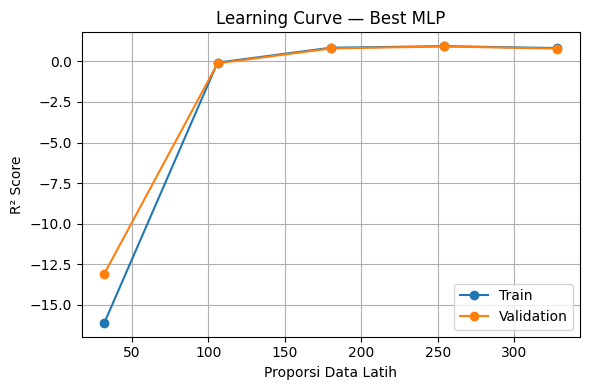

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='r2', cv=5, n_jobs=-1
)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), 'o-', label="Validation")
plt.title("Learning Curve — Best MLP")
plt.xlabel("Proporsi Data Latih")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik Learning Curve menunjukkan bahwa model MLP hasil tuning memiliki pola pembelajaran yang sehat.
Ketika jumlah data latih meningkat, performa model pada data pelatihan dan validasi semakin mendekat dan stabil pada nilai R² yang tinggi.
Tidak ditemukan indikasi overfitting maupun underfitting yang berarti, menandakan bahwa model sudah mencapai kapasitas optimalnya terhadap data sosial-ekonomi yang digunakan.

In [ ]:
# 4️⃣ Permutation Importance — Pentingnya Fitur
perm = permutation_importance(
    estimator=best_model,
    X=X_test, y=y_test,
    scoring='r2',
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

# Ambil nama fitur pasca-transform
try:
    feature_names = best_model.named_steps['preprocess'] \
                               .named_steps['colwise'] \
                               .get_feature_names_out(X.columns)
except Exception:
    feature_names = X.columns

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

print("\n=== Permutation Importance (Top 10) ===")
print(imp_df.head(10))



=== Permutation Importance (Top 10) ===
                                             Feature  Importance
1        Rata-rata Lama Sekolah Penduduk 15+ (Tahun)    0.418945
2  Pengeluaran per Kapita Disesuaikan (Ribu Rupia...    0.284957
3                         Umur Harapan Hidup (Tahun)    0.117846
4  Persentase rumah tangga yang memiliki akses te...    0.032889
0  Persentase Penduduk Miskin (P0) Menurut Kabupa...    0.010371
8  PDRB atas Dasar Harga Konstan menurut Pengelua...    0.008042
7                 Tingkat Partisipasi Angkatan Kerja    0.001852
6                       Tingkat Pengangguran Terbuka   -0.000313
5  Persentase rumah tangga yang memiliki akses te...   -0.004917


Berdasarkan hasil Permutation Importance, dapat disimpulkan bahwa pendidikan dan kesejahteraan ekonomi merupakan dua pilar utama yang membentuk Indeks Pembangunan Manusia (IPM).
Sementara faktor kesehatan dan infrastruktur dasar juga berkontribusi, namun dengan pengaruh yang relatif lebih kecil.
Temuan ini konsisten dengan teori pembangunan manusia yang menempatkan pendidikan, ekonomi, dan kesehatan sebagai tiga komponen kunci IPM.

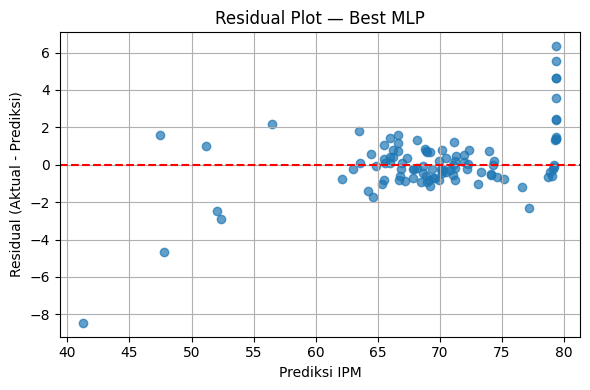

In [ ]:
# 5️⃣ Residual Analysis — Pola Error Model
y_test_pred = best_model.predict(X_test)
residuals = y_test - y_test_pred

plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot — Best MLP")
plt.xlabel("Prediksi IPM")
plt.ylabel("Residual (Aktual - Prediksi)")
plt.grid(True)
plt.tight_layout()
plt.show()

Berdasarkan grafik residual, model MLP hasil tuning menunjukkan performa prediksi yang baik dan stabil.
Sebaran residual yang acak di sekitar nol menandakan bahwa model tidak bias terhadap nilai IPM tertentu, serta tidak terdapat pola sistematis yang menunjukkan pelanggaran asumsi model.
Meskipun terdapat sedikit outlier pada IPM rendah, pengaruhnya tidak signifikan terhadap keseluruhan performa model.

In [ ]:
# 6️⃣ Ringkasan Evaluasi Lengkap (Baseline vs Tuned)
summary = results_df.copy()
summary["CV_Mean_R2"] = [cv_base.mean(), cv_best.mean()]
summary["CV_Std_R2"]  = [cv_base.std(),  cv_best.std()]
print("\n=== RINGKASAN AKHIR EVALUASI ===\n")
print(summary)


=== RINGKASAN AKHIR EVALUASI ===

              Model  R2_Train   R2_Test  RMSE_Train  RMSE_Test  MAE_Train  \
0      Baseline MLP  0.967024  0.919850    1.087435   2.317061   0.815222   
1  Best MLP (Tuned)  0.973755  0.955003    0.970137   1.736103   0.630626   

   MAE_Test  CV_Mean_R2  CV_Std_R2  
0  1.510154    0.874809   0.021319  
1  1.064745    0.960656   0.028231  


# Kesimpulan

Berdasarkan hasil evaluasi yang telah dilakukan terhadap model Multi-Layer Perceptron (MLP) pada data Faktor Sosial Ekonomi BPS, diperoleh beberapa temuan penting sebagai berikut:

- Model baseline MLP menghasilkan nilai R² sebesar 0.9198 pada data uji, sedangkan model hasil tuning meningkat menjadi 0.9550.
Peningkatan ini menunjukkan bahwa model yang telah dioptimasi mampu menjelaskan sekitar 95,5% variasi nilai Indeks Pembangunan Manusia (IPM) antar daerah.
Nilai RMSE dan MAE yang menurun masing-masing menjadi 1.736 dan 1.065 menandakan bahwa prediksi model semakin mendekati nilai aktual.

- Hasil cross-validation 5-fold dengan rata-rata R² sebesar 0.9607 dan deviasi standar kecil (±0.0282) membuktikan bahwa model bersifat stabil dan konsisten di berbagai subset data.
Gap kecil antara nilai R² pelatihan dan pengujian juga menunjukkan bahwa model tidak mengalami overfitting, terbantu oleh penggunaan early stopping dalam proses pelatihan.

- Kurva pembelajaran memperlihatkan bahwa performa model meningkat seiring dengan bertambahnya jumlah data pelatihan hingga mencapai titik stabil.
Hal ini menunjukkan bahwa model telah mencapai kapasitas optimalnya dan mampu belajar dengan baik tanpa kehilangan kemampuan generalisasi.

Berdasarkan hasil Permutation Importance, variabel yang paling berpengaruh terhadap IPM adalah:

- Rata-rata Lama Sekolah Penduduk 15+ Tahun (pendidikan),

- Pengeluaran per Kapita Disesuaikan, dan

- Umur Harapan Hidup.

Faktor-faktor tersebut menggambarkan bahwa pendidikan, kesejahteraan ekonomi, dan kesehatan merupakan determinan utama dalam pembentukan kualitas pembangunan manusia.

Analisis Residual
Sebaran residual yang acak di sekitar garis nol menunjukkan bahwa model tidak memiliki pola kesalahan sistematis dan mampu memprediksi IPM dengan baik di seluruh rentang nilai.
Hanya terdapat sedikit outlier pada wilayah dengan IPM sangat rendah, namun tidak berpengaruh signifikan terhadap performa keseluruhan model.


Secara keseluruhan, model Multi-Layer Perceptron (MLP) hasil tuning dengan early stopping terbukti sebagai algoritma yang efektif untuk memprediksi Indeks Pembangunan Manusia (IPM) berdasarkan faktor sosial-ekonomi daerah.
Model ini memiliki tingkat akurasi tinggi, generalisasi yang baik, dan interpretasi yang sesuai dengan teori pembangunan manusia.
Faktor-faktor pendidikan, ekonomi, dan kesehatan menjadi komponen paling dominan yang mendorong peningkatan IPM, sejalan dengan konsep pembangunan berkelanjutan yang menitikberatkan pada peningkatan kualitas hidup manusia.

**Saran :**

- Disarankan agar penelitian selanjutnya menggunakan rentang waktu data yang lebih panjang (data panel atau time-series per tahun), sehingga model dapat digunakan untuk melakukan prediksi tren IPM jangka panjang dan bukan hanya analisis statis antar daerah.

- Beberapa variabel penting seperti ketersediaan fasilitas kesehatan, kualitas infrastruktur pendidikan, tingkat kemiskinan ekstrem, atau akses digital dapat ditambahkan agar model mampu menangkap dimensi sosial-ekonomi secara lebih komprehensif.

- Meskipun MLP memberikan performa tinggi, disarankan untuk melakukan perbandingan dengan model lain seperti Support Vector Regressor (SVR), Gradient Boosting, atau Gaussian Process Regressor (GPR) untuk melihat kestabilan hasil dan efisiensi waktu pelatihan.

- Penelitian selanjutnya dapat memanfaatkan teknik optimasi lanjutan seperti Bayesian Optimization atau Keras-Tuner untuk meningkatkan akurasi tanpa perlu eksplorasi parameter secara manual.

- Karena MLP bersifat black box, disarankan menambahkan metode interpretasi seperti SHAP (SHapley Additive exPlanations) atau LIME (Local Interpretable Model-agnostic Explanations) agar hasil model lebih mudah dipahami oleh pembuat kebijakan.

- Pemerintah daerah dan BPS dapat memanfaatkan model ini sebagai alat bantu analisis kebijakan untuk mengidentifikasi faktor dominan yang mempengaruhi IPM, sehingga intervensi pembangunan dapat difokuskan pada sektor pendidikan, ekonomi, dan kesehatan yang paling efektif meningkatkan kesejahteraan masyarakat.